In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

from studio_preprocessing_tools import *

In [10]:
proteingym_dir = "/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/"
from bioviper import readSequences
norA_wt = readSequences(f"{proteingym_dir}/DMS_assays/raw_data/NORA_STAAU_Miller_2025/wt_seq.fasta")
norA_wt = str(norA_wt[0].seq)

substrates = ['acriflavine', 'ethidium', 'norfloxacin', 'ofloxacin', 'pentamidine', 'pipemidic acid', 'puromycin', 'TPP', 'no drug']
dfs = {}

for substrate in substrates:
    dfs[substrate] = pd.read_excel(f"{proteingym_dir}/DMS_assays/raw_data/NORA_STAAU_Miller_2025/supp_specificity_data.xlsx", sheet_name=substrate).set_index("mut")

    combined_df = pd.concat(dfs.values(), 
                        keys=dfs.keys(), 
                        names=['substrate', 'variant'])

f_scores_combined = combined_df["f_score_combined_standardized"].unstack(level="substrate").dropna(axis=1, thresh=1)
f_scores_combined.loc['WT'] = np.zeros(8)
se_scores_combined = combined_df["SE_combined_standardized"].unstack(level="substrate").dropna(axis=1, thresh=1)

si_scores = f_scores_combined.max(axis=1) - f_scores_combined.min(axis=1)

#f_scores_combined['mutant'] = f_scores_combined.index

mean_scores = f_scores_combined[f_scores_combined.columns[:7]].mean(axis=1)
f_scores_combined['mean_score'] = mean_scores
f_scores_combined['si_score'] = si_scores

print(f"Length of NorA WT sequence: {len(norA_wt[0])}")

Length of NorA WT sequence: 1


Text(0.5, 0, 'Specificity importance score')

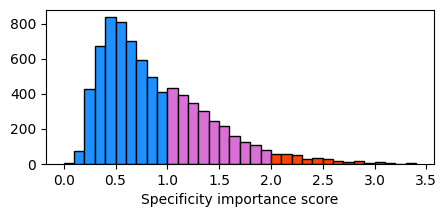

In [13]:
plt.figure(figsize=(5,2))
plt.hist(f_scores_combined.si_score, ec='k', bins=np.arange(0, 1.1, 0.1), color='dodgerblue');
plt.hist(f_scores_combined.si_score, ec='k', bins=np.arange(1.0, 2.1, 0.1), color='orchid');
plt.hist(f_scores_combined.si_score, ec='k', bins=np.arange(2.0, 3.5, 0.1), color='orangered');
plt.xlabel("Specificity importance score")

In [18]:
norA_dataset.loc['WT']

substrate
acriflavine                                                           0.0
ethidium                                                              0.0
norfloxacin                                                           0.0
ofloxacin                                                             0.0
pentamidine                                                           0.0
pipemidic acid                                                        0.0
puromycin                                                             0.0
TPP                                                                   0.0
mean_score                                                            0.0
si_score                                                              0.0
mutant                                                                M1M
specificity_category                                   native-specificity
n_subs                                                                  0
mutated_sequence        MNKQ

In [19]:
norA_dataset = f_scores_combined.loc[['_' not in i for i in f_scores_combined.index]]

norA_dataset = assign_mutant_column(norA_dataset)

norA_dataset = assign_specificity_categories(norA_dataset,
                              lambda index,row: row.mean_score<-1,
                              lambda index,row: row.si_score>1.5)

norA_dataset.loc[:, 'n_subs'] = [i.count(':')+1 if i!='M1M' else 0 for i in norA_dataset.mutant]
norA_dataset.loc[:, 'mutated_sequence'] = [apply_mutations(norA_wt, muts) for muts in norA_dataset.mutant]
norA_dataset.loc[:, 'DMS_score'] = norA_dataset['ofloxacin']

print(len(norA_dataset))

/n/groups/marks/users/sam/SpecificityStudio/notebooks/Assay processing notebooks/studio_preprocessing_tools.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mutant'] = pd.Series(mutants, index=df.index)


7344


In [21]:
check_dataset(norA_dataset)

norA_dataset.to_csv("../../processed_data/NORA_STAAU_Miller_2025.csv")

Checking dataset table:
✅ DMS_score in table
✅ mutated_sequence in table
✅ mutant in table
✅ Contains WT sequence (M1M)
✅ all mutants pass checks and match sequence

✅ All checks passed!


In [22]:
np.savetxt('../../processed_data/norA_ESCOTT.mut', norA_dataset.mutant.values, fmt="%s")
np.savetxt('../../processed_data/norA_GEMME.mut', [i.replace(':',',') for i in norA_dataset.mutant.values], fmt="%s")